# Tutorial 4: TLS Heterogeneity in Clear-Cell Renal Cell Carcinoma

Tertiary lymphoid structures (TLS) are tumor-infiltrating lymphoid aggregates whose composition varies between patients and is associated with prognosis. This tutorial uses QueST to (1) train a niche embedding on 15 ccRCC Visium slices spanning 28 annotated TLS, (2) extract per-TLS embeddings, and (3) reveal three coherent TLS subtypes via UMAP.

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys
import logging
import warnings
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
import sys, os
import quest.utils as utils
from quest.trainer import QueSTTrainer

In [ ]:
warnings.filterwarnings('ignore')
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.WARNING)

## 1. Load data

We use 15 of the 18 ccRCC slices (3 frozen slices `frozen_c_5 / c_2 / c_23` are excluded due to lower quality). The remaining slices contain 28 annotated TLS in `obs['tls_group']`, with `'NO_TLS'` for non-TLS spots.

In [ ]:
dataset = 'ccRCC'
data_path = '../data/ccRCC'
model_path = '../results/ccRCC/model/quest_model.pth'
embedding_folder = '../results/ccRCC/embedding'

sample_ids = [
    'ffpe_c_2',  'ffpe_c_3',    'ffpe_c_4',   'ffpe_c_7',   'ffpe_c_20',  'ffpe_c_34',
    'ffpe_c_36', 'ffpe_c_39',   'ffpe_c_45',  'ffpe_c_51',  'frozen_a_3', 'frozen_a_15',
    'frozen_b_1','frozen_b_18', 'frozen_c_57',
]
adata_list = [sc.read_h5ad(f'{data_path}/{sid}.h5ad') for sid in sample_ids]
print(f'Loaded {len(adata_list)} slices, {sum(a.n_obs for a in adata_list)} spots total')

Loaded 15 slices, 50462 spots total


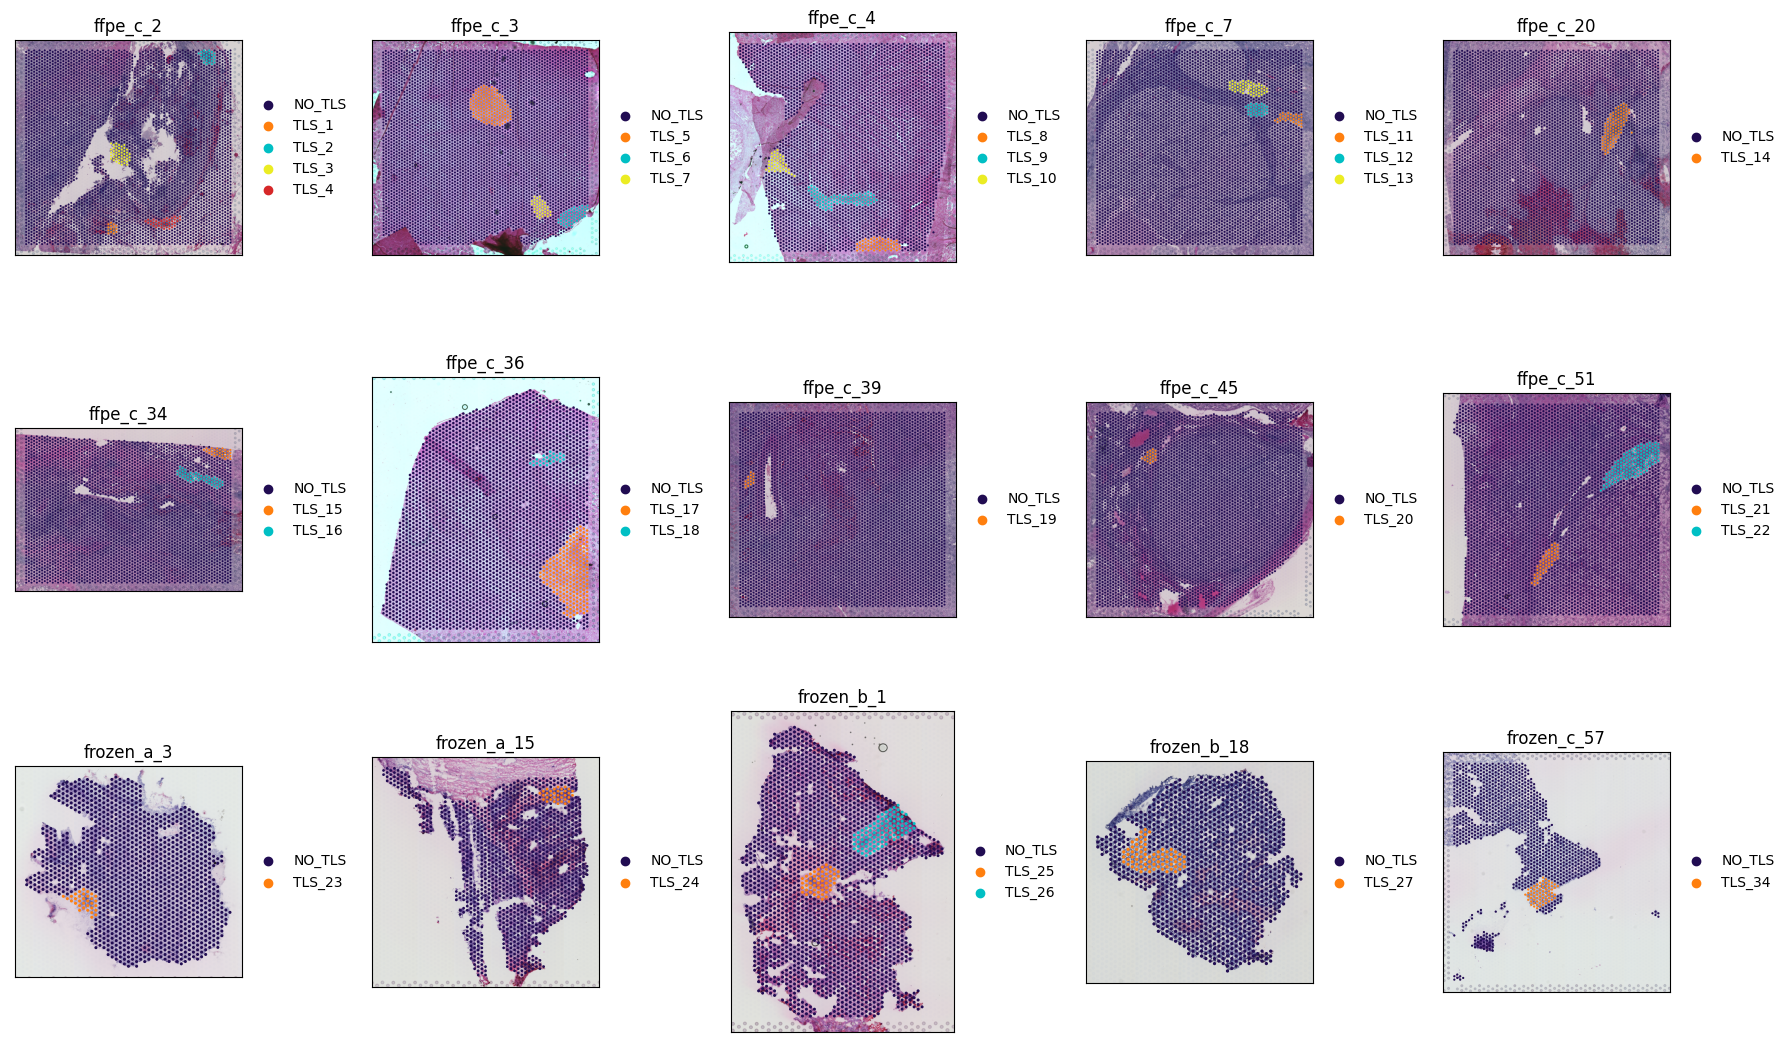

In [ ]:
color_list = ['#210c52', '#ff7f0e', '#00bfc4', '#ebec23', '#d62728']
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(18, 11))
axes = axes.flatten()
for i, (sid, adata) in enumerate(zip(sample_ids, adata_list)):
    n_grp = len(np.unique(adata.obs['tls_group']))
    sc.pl.spatial(adata, color='tls_group', palette=color_list[:n_grp],
                  ax=axes[i], show=False, title=sid)
    axes[i].set_xlabel(''); axes[i].set_ylabel('')
fig.tight_layout()
plt.show()

## 2. Train QueST

In [ ]:
trainer = QueSTTrainer(
    dataset=dataset, data_path=data_path,
    sample_ids=sample_ids, adata_list=adata_list,
    query_niches=None, query_sample_id=None,
    model_path=model_path,
    embedding_folder=embedding_folder,
    epochs=15, save_model=True,
    hvg=4000, min_count=None, normalize=True,
    seed=2024,
)

We also provided pretrained QueST model checkpoint weights at https://cloud.tsinghua.edu.cn/d/d649dc24501b4958905e/. To skip training and use pretrained checkpoint, simiply put it at corresponding model path and comment the "trainer.train()" line.

In [ ]:
trainer.train()
trainer.inference(ckpt_path=model_path)

training: 100%|██████████| 15/15 [12:14<00:00, 48.96s/epoch]


## 3. Extract per-TLS embeddings

In [ ]:
tls_emb_dict = utils.get_subgraph_embedding(
    trainer.model, trainer.adata_list, trainer.feature_list, trainer.edge_ind_list,
    group_key='tls_group', exclude_values=['NO_TLS'],
)

TLS_GROUPS = {
    'Group A':  [f'TLS_{i}' for i in [11, 12, 13, 17, 18, 21, 22]],
    'Group B1': [f'TLS_{i}' for i in [1, 2, 4, 10, 14, 15, 16, 23, 34]],
    'Group B2': [f'TLS_{i}' for i in [3, 5, 6, 7, 8, 9, 19, 20, 24, 25, 26, 27]],
}
tls_adata = utils.wrap_subgraph_dict(tls_emb_dict, TLS_GROUPS)

## 4. Visualize the TLS embedding space

Hierarchical clustering of the 28 TLS embeddings yields three coherent subtypes:
- **Group A** (7 TLS) — stromal / fibrotic, associated with poor prognosis;
- **Group B1** (9 TLS) — B-cell mature, GC-like;
- **Group B2** (12 TLS) — inflamed / IFN-γ active.

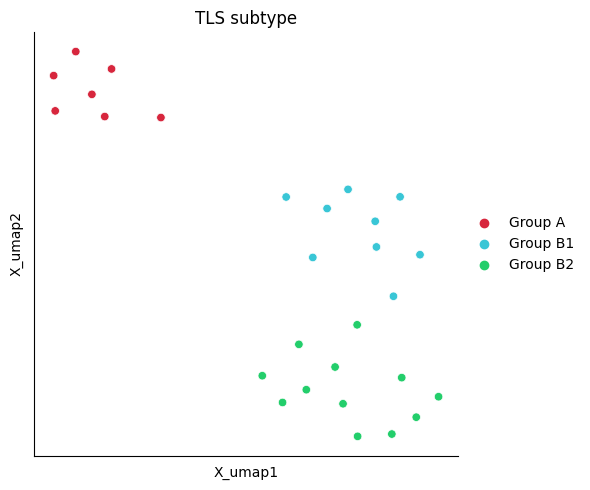

In [ ]:
utils.plot_niche_umap(
    tls_adata, color='group', figsize=(6, 5), size=100,
    palette={'Group A': '#d7263d', 'Group B1': '#39c6d6', 'Group B2': '#23ce6b'},
    frameon=True, edge_color='white', linewidths=0.5,
    hide_ticks=True, hide_spines=True,
    invert_x=True, invert_y=True,
    title='TLS subtype',
)